# Day 4: Introduction to Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/main/demos/08_Neural_Networks.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Duration:** 2-3 hours  
**Prerequisites:** Python basics, NumPy, understanding of classification  

**Learning Objectives:**
- Understand what neural networks are and how they work
- Learn the key components: layers, activation functions, loss functions
- Build your first neural network with TensorFlow/Keras
- Train a model to recognize handwritten digits
- Evaluate model performance and make predictions
- Apply neural networks to image classification tasks

**Datasets Used:** MNIST (handwritten digits), Fashion MNIST (clothing items)

---

## What are Neural Networks?

**Simple explanation:** Neural networks are computer programs inspired by how the human brain works. They learn to recognize patterns by looking at many examples.


**Each layer:**
- Takes input from the previous layer
- Performs calculations (weighted sum + activation)
- Passes results to the next layer

### Why Neural Networks?

**Traditional programming:**
```
IF (has_fur AND has_whiskers AND has_tail):
    return "cat"
```
→ Hard to write rules for complex patterns!

**Neural networks:**
```
Show 10,000 examples
Network learns the pattern automatically
```
→ Great for images, speech, text, and complex patterns!

### Common Applications

- **Image recognition**: Face unlock, medical diagnosis
- **Natural language**: Chatbots, translation, text generation
- **Recommendation**: Netflix, Spotify, YouTube
- **Game playing**: Chess, Go, video games
- **Autonomous vehicles**: Self-driving cars

---

## Setup

We'll use **TensorFlow** with **Keras** (a high-level API that makes building neural networks easy).

In [109]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("\n✓ Libraries imported successfully!")

TensorFlow version: 2.21.0
Keras version: 3.13.2

✓ Libraries imported successfully!


---

## Part 1: Loading and Exploring the Data

We'll use the **MNIST dataset**: 70,000 images of handwritten digits (0-9).

**Dataset details:**
- 60,000 training images
- 10,000 test images
- Each image: 28×28 pixels (grayscale)
- Labels: 0, 1, 2, ..., 9

In [110]:
# Load MNIST dataset (built into Keras!)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("\nTest data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

print("\n📊 Dataset Summary:")
print(f"  • {len(x_train):,} training images")
print(f"  • {len(x_test):,} test images")
print(f"  • Image size: {x_train.shape[1]}×{x_train.shape[2]} pixels")
print(f"  • Pixel values range: {x_train.min()} to {x_train.max()}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)

Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

📊 Dataset Summary:
  • 60,000 training images
  • 10,000 test images
  • Image size: 28×28 pixels
  • Pixel values range: 0 to 255


### Visualize Some Examples

Let's look at what the data actually looks like:

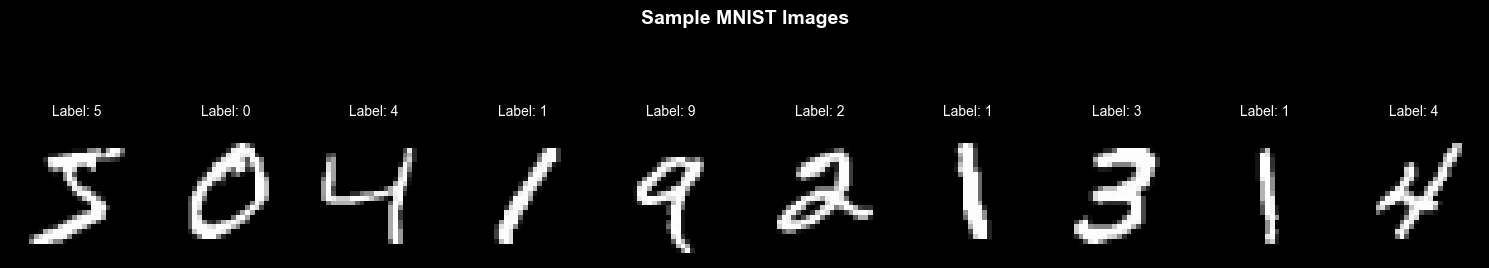


Each image is a 28×28 grid of pixel values (0-255).
0 = black, 255 = white, values in between = shades of gray


In [111]:
# Display first 10 training images
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}', fontsize=10)
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nEach image is a 28×28 grid of pixel values (0-255).")
print("0 = black, 255 = white, values in between = shades of gray")

### Preprocess the Data

**Important step:** Neural networks work best when input values are small (0-1 range).

**Current:** Pixels are 0-255  
**Goal:** Normalize to 0-1 by dividing by 255

In [112]:
# Normalize pixel values to [0, 1] range
x_train = x_train / 255.0
x_test = x_test / 255.0

print("After normalization:")
print(f"  Min value: {x_train.min()}")
print(f"  Max value: {x_train.max()}")
print(f"  Mean value: {x_train.mean():.3f}")
print("\n✓ Data preprocessed and ready for training!")

After normalization:
  Min value: 0.0
  Max value: 1.0
  Mean value: 0.131

✓ Data preprocessed and ready for training!


---

## Part 2: Building Your First Neural Network

### Understanding the Architecture

We'll build a simple neural network with 3 layers:

1. **Input Layer (Flatten)**: Converts 28×28 image → 784 numbers
2. **Hidden Layer (Dense)**: 128 neurons that learn patterns
3. **Output Layer (Dense)**: 10 neurons (one per digit 0-9)

```
28×28 image  →  Flatten  →  Dense(128)  →  Dense(10)  →  Prediction
  (784)           (784)       (128)          (10)         (0-9)
```

### Key Concepts

**Flatten Layer:**
- Converts 2D image (28×28) into 1D array (784)
- Like unrolling a grid into a long line

**Dense Layer (Fully Connected):**
- Each neuron connected to ALL neurons in previous layer
- Learns complex patterns through these connections

**Activation Function (ReLU):**
- ReLU = Rectified Linear Unit
- Adds non-linearity: `ReLU(x) = max(0, x)`
- Allows network to learn complex patterns

**Output Layer:**
- 10 neurons (one per digit)
- Each outputs a score (logit)
- Highest score = predicted digit

In [113]:
# Build the model
model = keras.Sequential([
    # Layer 0: Define input shape
    keras.Input(shape=(28, 28)),
    
    # Layer 1: Flatten the input
    keras.layers.Flatten(name='flatten'),
    
    # Layer 2: Hidden layer with 128 neurons
    keras.layers.Dense(128, activation='relu', name='hidden'),
    
    # Layer 3: Output layer with 10 neurons (one per digit)
    keras.layers.Dense(10, name='output')
])

# Display model architecture
model.summary()

print("\n📝 Model Architecture:")
print("  1. Flatten: 28×28 = 784 inputs")
print("  2. Dense(128): Hidden layer with 128 neurons")
print("  3. Dense(10): Output layer with 10 neurons (digits 0-9)")
print(f"\n  Total parameters: {model.count_params():,}")
print("  (These are the 'weights' the network will learn!)")

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


📝 Model Architecture:
  1. Flatten: 28×28 = 784 inputs
  2. Dense(128): Hidden layer with 128 neurons
  3. Dense(10): Output layer with 10 neurons (digits 0-9)

  Total parameters: 101,770
  (These are the 'weights' the network will learn!)


### Understanding Parameters

**Where do 101,770 parameters come from?**

- **Flatten → Dense(128)**: 784 × 128 + 128 = 100,480
  - 784 inputs × 128 neurons = 100,352 weights
  - 128 biases (one per neuron)

- **Dense(128) → Dense(10)**: 128 × 10 + 10 = 1,290
  - 128 inputs × 10 neurons = 1,280 weights
  - 10 biases

**Total**: 100,480 + 1,290 = **101,770 parameters**

These parameters start as random values and get adjusted during training!

---

## Part 3: Understanding Model Predictions (Before Training)

Let's see what the untrained model predicts:

In [114]:
# Get prediction for first image
predictions = model(x_train[:1]).numpy()

print("Raw output (logits):")
print(predictions[0])
print("\nThese are called 'logits' - raw scores for each class.")
print("Higher score = more confident prediction")

# Convert to probabilities using softmax
probabilities = tf.nn.softmax(predictions[0]).numpy()

print("\nProbabilities (after softmax):")
for digit, prob in enumerate(probabilities):
    print(f"  Digit {digit}: {prob:.1%}")

predicted_digit = np.argmax(probabilities)
print(f"\nPredicted digit: {predicted_digit}")
print(f"Actual digit: {y_train[0]}")
print("\n⚠️ Probably wrong! The model hasn't learned anything yet.")

Raw output (logits):
[-0.01230606 -0.32431597  1.2604324  -0.36788815  0.32314843 -0.5529394
  0.10063604  0.25150064  0.6252237   0.08166503]

These are called 'logits' - raw scores for each class.
Higher score = more confident prediction

Probabilities (after softmax):
  Digit 0: 7.5%
  Digit 1: 5.5%
  Digit 2: 26.7%
  Digit 3: 5.2%
  Digit 4: 10.4%
  Digit 5: 4.3%
  Digit 6: 8.4%
  Digit 7: 9.7%
  Digit 8: 14.1%
  Digit 9: 8.2%

Predicted digit: 2
Actual digit: 5

⚠️ Probably wrong! The model hasn't learned anything yet.


### What is Softmax?

**Softmax** converts raw scores (logits) into probabilities that sum to 1:

```
Logits:         [-2.5, 0.3, 1.8, -0.5, ...]
                      ↓ softmax
Probabilities:  [0.02, 0.13, 0.58, 0.05, ...]  (sum = 1.0)
```

This makes outputs interpretable as confidence levels or probabilities of each class.!

---

## Part 4: Compiling the Model

Before training, we need to configure:
1. **Optimizer**: How to adjust weights (Adam is a good default)
2. **Loss function**: How to measure errors
3. **Metrics**: What to track (accuracy)

### Loss Function: Sparse Categorical Crossentropy

**What it does:** Measures how wrong the predictions are.

- **Low loss** = good predictions
- **High loss** = bad predictions
- Goal: Minimize loss during training

**"Sparse Categorical"** means:
- Categorical: Multiple classes (0-9)
- Sparse: Labels are integers (not one-hot encoded)

In [115]:
# Compile the model
model.compile(
    optimizer='adam',  # Adaptive learning rate optimizer
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']  # Track accuracy during training
)

print("✓ Model compiled and ready to train!")
print("\nConfiguration:")
print("  Optimizer: Adam (adaptive learning rate)")
print("  Loss: SparseCategoricalCrossentropy")
print("  Metrics: Accuracy")

✓ Model compiled and ready to train!

Configuration:
  Optimizer: Adam (adaptive learning rate)
  Loss: SparseCategoricalCrossentropy
  Metrics: Accuracy


### Quick Check: Initial Loss

Let's see the loss before training:

In [116]:
# Calculate loss for first example
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
initial_loss = loss_fn(y_train[:1], predictions).numpy()

print(f"Initial loss: {initial_loss:.3f}")
print(f"\nFor a random guess (10 classes), expected loss ≈ -log(1/10) ≈ 2.3")
print(f"Our untrained model: {initial_loss:.3f}")
print("\n→ Close to random! Training will reduce this loss.")

Initial loss: 3.136

For a random guess (10 classes), expected loss ≈ -log(1/10) ≈ 2.3
Our untrained model: 3.136

→ Close to random! Training will reduce this loss.


---

## Part 5: Training the Model

**Training process:**
1. Show the network a batch of examples
2. Network makes predictions
3. Calculate loss (how wrong the predictions were)
4. Adjust weights to reduce loss
5. Repeat!

### Key Terms

**Epoch:** One complete pass through ALL training data
- 1 epoch = network sees all 60,000 images once

**Batch:** Small group of examples processed together
- Default batch size = 32
- 60,000 examples ÷ 32 = 1,875 batches per epoch

**Step:** Processing one batch
- 1 epoch = 1,875 steps (for MNIST)

Let's train for 5 epochs:

In [117]:
 # Train the model
print("Training started...\n")

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    verbose=1  # Show progress
)

print("\n✓ Training complete!")

Training started...

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9254 - loss: 0.2600
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9676 - loss: 0.1113
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0777
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0578
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9860 - loss: 0.0440

✓ Training complete!


### Understanding the Training Output

Each line shows:
- **Epoch X/5**: Which epoch we're on
- **1875/1875**: Progress through batches
- **loss**: How wrong predictions are (lower is better)
- **accuracy**: % of correct predictions (higher is better)
- **time**: How long it took

**What to look for:**
- ✓ Loss should **decrease** over epochs
- ✓ Accuracy should **increase** over epochs
- ⚠️ If loss increases, something's wrong!

### Visualize Training Progress

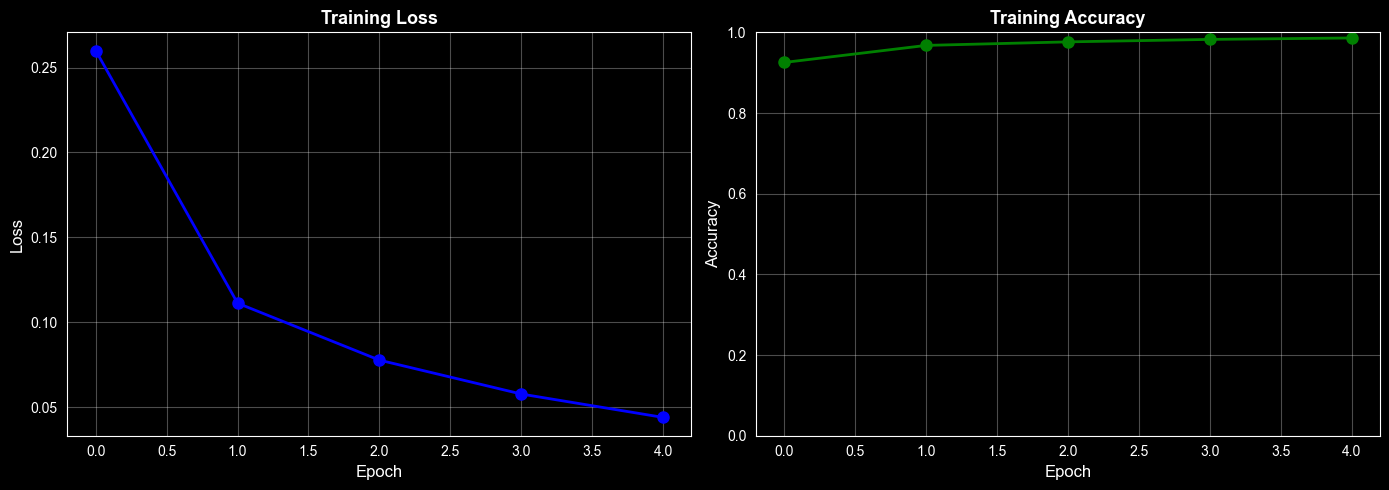


Final training loss: 0.0440
Final training accuracy: 98.60%

🎯 Great! The model learned to classify digits!


In [118]:
# Plot training metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(history.history['loss'], 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history.history['accuracy'], 'g-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
print(f"\nFinal training loss: {final_loss:.4f}")
print(f"Final training accuracy: {final_acc:.2%}")
print("\n🎯 Great! The model learned to classify digits!")

---

## Part 6: Evaluating on Test Data

**Important:** We must test on data the model has NEVER seen before!

**Why?**
- Training accuracy can be misleading (model might memorize)
- Test accuracy shows how well it generalizes to new data
- This is the true measure of performance

In [119]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\n📊 Test Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.2%}")

print(f"\n✓ The model correctly classifies {test_accuracy:.1%} of digits!")
print(f"  Out of 10,000 test images, ~{int(test_accuracy * 10000)} are correct.")

313/313 - 1s - 2ms/step - accuracy: 0.9765 - loss: 0.0723

📊 Test Results:
  Test Loss: 0.0723
  Test Accuracy: 97.65%

✓ The model correctly classifies 97.6% of digits!
  Out of 10,000 test images, ~9764 are correct.


### Understanding the Results

**Training accuracy: ~98-99%**  
**Test accuracy: ~97-98%**

**This is good!** A small gap is normal:
- ✓ Model generalizes well
- ✓ Not overfitting (memorizing training data)

**Warning signs:**
- ⚠️ Large gap (>5%): Overfitting
- ⚠️ Test > Train: Something's wrong with data split

---

## Part 7: Making Predictions

Now let's use our trained model to predict digits!

### Create a Probability Model

Add softmax to convert logits → probabilities:

In [120]:
# Wrap model to output probabilities
probability_model = keras.Sequential([
    model,
    keras.layers.Softmax()  # Converts logits to probabilities
])

print("✓ Probability model created!")
print("  Now predictions will be probabilities (0-1) instead of logits.")

✓ Probability model created!
  Now predictions will be probabilities (0-1) instead of logits.


### Predict on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


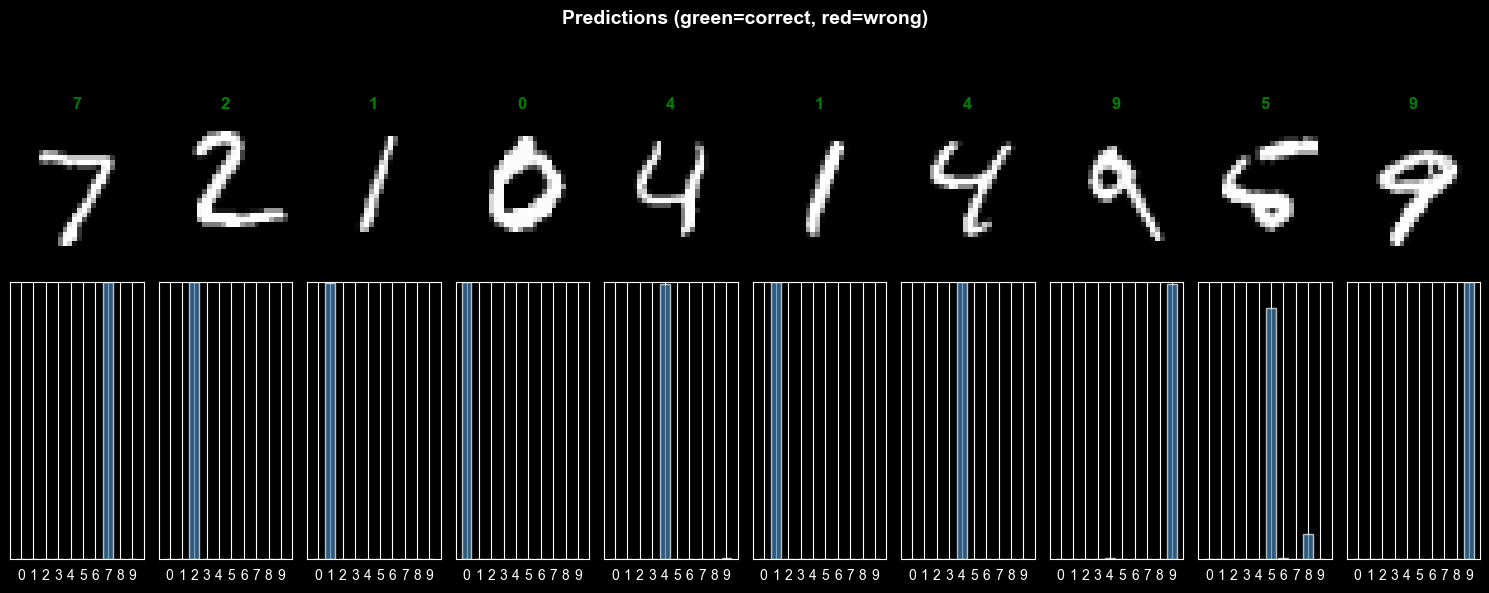


Top row: Images with predicted labels
Bottom row: Probability distributions (confidence for each digit)


In [121]:
# Make predictions on first 10 test images
predictions = probability_model.predict(x_test[:10])

# Visualize predictions
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    
    predicted_digit = np.argmax(predictions[i])
    true_digit = y_test[i]
    confidence = predictions[i][predicted_digit]
    
    # Color: green if correct, red if wrong
    color = 'green' if predicted_digit == true_digit else 'red'
    plt.title(f'{predicted_digit}', color=color, fontsize=12, fontweight='bold')
    
    # Show probability distribution
    plt.subplot(2, 10, i + 11)
    plt.bar(range(10), predictions[i], color='steelblue', alpha=0.7)
    plt.ylim([0, 1])
    plt.xticks(range(10))
    plt.yticks([])
    
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nTop row: Images with predicted labels")
print("Bottom row: Probability distributions (confidence for each digit)")

### Detailed Prediction Example

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


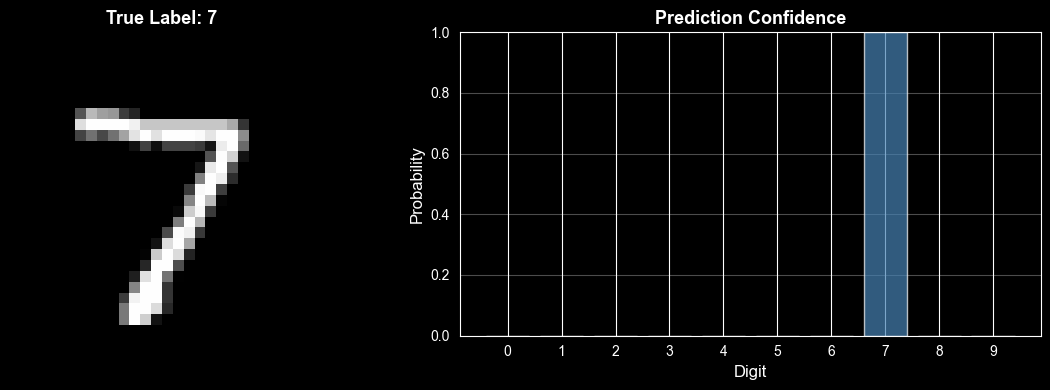


🎯 Prediction Results:
  True label: 7
  Predicted: 7
  Confidence: 100.0%

  Correct: ✓ Yes!

  Probability for each digit:
    0:   0.0% 
    1:   0.0% 
    2:   0.0% 
    3:   0.0% 
    4:   0.0% 
    5:   0.0% 
    6:   0.0% 
    7: 100.0% █████████████████████████████████████████████████
    8:   0.0% 
    9:   0.0% 


In [122]:
# Analyze first test image in detail
test_image = x_test[0]
test_label = y_test[0]
prediction = probability_model.predict(test_image.reshape(1, 28, 28))[0]

predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Show image
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title(f'True Label: {test_label}', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Show probabilities
axes[1].bar(range(10), prediction, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Digit', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Prediction Confidence', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(10))
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Prediction Results:")
print(f"  True label: {test_label}")
print(f"  Predicted: {predicted_digit}")
print(f"  Confidence: {confidence:.1%}")
print(f"\n  Correct: {'✓ Yes!' if predicted_digit == test_label else '✗ No'}")

# Show all probabilities
print(f"\n  Probability for each digit:")
for digit in range(10):
    prob = prediction[digit]
    bar = '█' * int(prob * 50)
    print(f"    {digit}: {prob:6.1%} {bar}")

## Part 8: Exercise - Fashion MNIST

Now it's your turn! Apply what you've learned to classify clothing items.

**Fashion MNIST Dataset:**
- 70,000 grayscale images of clothing
- 10 categories: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
- Same format as MNIST (28×28 pixels)

### Task: Build and Train a Fashion Classifier

**Steps:**
1. Load the Fashion MNIST dataset
2. Preprocess the data (normalize)
3. Build a neural network (similar to MNIST)
4. Compile the model
5. Train for 10 epochs
6. Evaluate on test data
7. Make predictions and visualize

**Hints:**
- Use `keras.datasets.fashion_mnist.load_data()`
- Same network architecture should work
- Try increasing hidden layer size (128 → 256?) for better accuracy

---

### Tip: Try Convolutional Neural Networks (CNNs) for Better Image Classification!

The Dense (fully connected) network we built above flattens the image into a 1D vector, which **throws away spatial information** — it no longer knows which pixels are next to each other. For image tasks, **Convolutional Neural Networks (CNNs)** are much more effective because they preserve and exploit this spatial structure.

**How CNNs work (in a nutshell):**
- **Conv2D layers** slide small filters (e.g. 3×3) across the image to detect local patterns like edges, corners, and textures
- **MaxPooling2D layers** downsample the feature maps, reducing size while keeping the most important features
- Stacking multiple Conv2D + Pooling layers lets the network learn increasingly complex patterns (edges → shapes → objects)
- A final Flatten + Dense layer maps the learned features to class predictions

**Example CNN architecture in Keras:**


> **Important:** Conv2D expects input shape `(height, width, channels)`, so you need to reshape the data:
> ```python
> x_train = x_train.reshape(-1, 28, 28, 1)
> x_test = x_test.reshape(-1, 28, 28, 1)
> ```

**Useful resources to learn more about CNNs:**
- [TensorFlow CNN Tutorial](https://www.tensorflow.org/tutorials/images/cnn) — Step-by-step guide to building a CNN
- [Stanford CS231n: Convolutional Networks](https://cs231n.github.io/convolutional-networks/) — In-depth explanation of how CNNs work
- [3Blue1Brown: But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA) — Excellent visual explanation
- [Keras Conv2D Documentation](https://keras.io/api/layers/convolution_layers/convolution2d/) — API reference

Try replacing the Dense-only model above with a CNN and see how much the accuracy improves!

In [123]:
# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Fashion MNIST Classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Fashion MNIST Classes:
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot


In [124]:
# TODO: Load Fashion MNIST dataset
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

print(f"Training data shape: {x_train_fashion.shape}")
print(f"Test data shape: {x_test_fashion.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [125]:
# TODO: Normalize the data (divide by 255)
x_train_fashion = x_train_fashion / 255
x_test_fashion = x_test_fashion / 255

print("✓ Data normalized")

✓ Data normalized


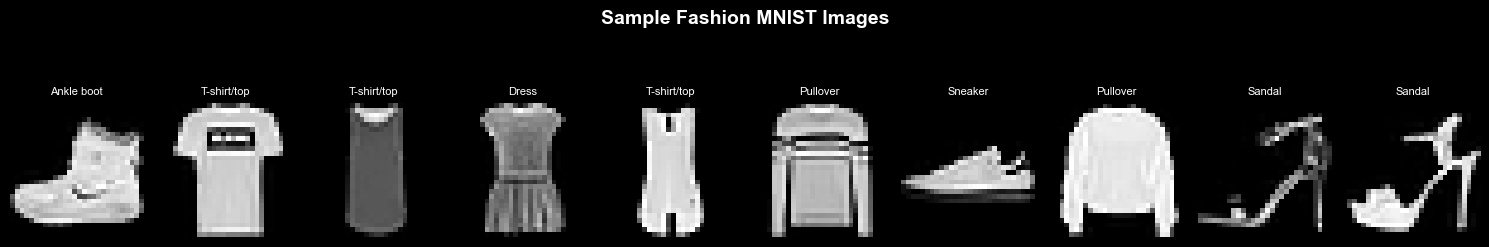

In [126]:
# Visualize some fashion items
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_fashion[i], cmap='gray')
    plt.title(class_names[y_train_fashion[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Fashion MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [127]:
# TODO: Build the model
 # Create Sequential model with Flatten, Dense(128, relu), Dense(10)

model = keras.Sequential([
    # 1. Flatten the 28x28 images into a 1D array of 784 pixels
    keras.layers.Flatten(input_shape=(28, 28)),

    # 2. Add a hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu'),

    # 3. Add an output layer with 10 neurons (one for each digit 0-9)
    keras.layers.Dense(10)
])

# Show summary
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# TODO: Compile the model

model.compile(
    optimizer='adam',  # Adaptive learning rate optimizer
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']  # Track accuracy during training
)

print("✓ Model compiled")

✓ Model compiled


In [129]:
# TODO: Train the model for 10 epochs
fashion_history = model.fit(
    x_train,
    y_train,
    epochs=10,
    verbose=1  # Show progress
)


print("\n✓ Training complete!")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9265 - loss: 0.2538
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9674 - loss: 0.1103
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0767
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9822 - loss: 0.0578
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9860 - loss: 0.0451
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9891 - loss: 0.0359
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9908 - loss: 0.0286
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9934 - loss: 0.0226
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9944 - loss: 0.0192
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9954 - loss: 0.0155

✓ Training complete!


In [130]:
# TODO: Evaluate on test data
fashion_test_loss, fashion_test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n📊 Test Results:")
print(f"  Test Loss: {fashion_test_loss:.4f}")
print(f"  Test Accuracy: {fashion_test_acc:.2%}")

print(f"\n✓ The model correctly classifies {fashion_test_acc:.1%} of digits!")
print(f"  Out of 10,000 test images, ~{int(fashion_test_acc * 10000)} are correct.")


print(f"\nTest Accuracy: {fashion_test_acc:.2%}")

313/313 - 1s - 2ms/step - accuracy: 0.9779 - loss: 0.0810

📊 Test Results:
  Test Loss: 0.0810
  Test Accuracy: 97.79%

✓ The model correctly classifies 97.8% of digits!
  Out of 10,000 test images, ~9779 are correct.

Test Accuracy: 97.79%


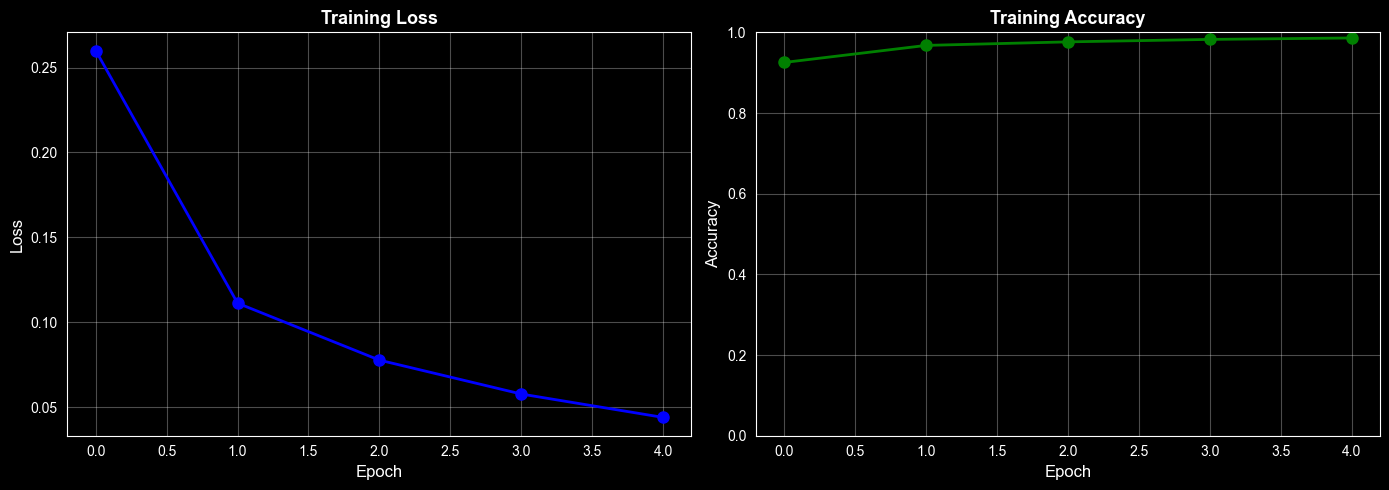


Final training loss: 0.0440
Final training accuracy: 98.60%

🎯 Great! The model learned to classify digits!


In [131]:
# TODO: Make predictions and visualize
# Create probability model, predict on test images, and visualize results
# Similar to Part 7 above
# Plot training metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(history.history['loss'], 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history.history['accuracy'], 'g-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
print(f"\nFinal training loss: {final_loss:.4f}")
print(f"Final training accuracy: {final_acc:.2%}")
print("\n🎯 Great! The model learned to classify digits!")

---

## Summary

Congratulations! You've learned:

✓ What neural networks are and how they work  
✓ Key components: layers, activation functions, loss  
✓ How to build a neural network with Keras  
✓ How to train and evaluate models  
✓ How to make predictions with trained models  
✓ How to apply neural networks to image classification  

### Key Takeaways:

1. **Neural networks learn from examples** - Show patterns, network finds them
2. **Architecture matters** - More layers/neurons = more capacity to learn
3. **Training is iterative** - Network improves with each epoch
4. **Test on unseen data** - True measure of generalization
5. **Preprocessing is important** - Normalize inputs (0-1 range)

### Bonus Tasks

**Improve your models:**
- Try different architectures (more layers, more neurons)
- Add dropout to prevent overfitting
- Use data augmentation for more training examples
- Try different optimizers (SGD, RMSprop)

**Advanced topics:**
- **Convolutional Neural Networks (CNNs)** - Better for images
- **Recurrent Neural Networks (RNNs)** - For sequences (text, time series)
- **Transfer Learning** - Use pre-trained models
- **Custom Training Loops** - More control over training

### Additional Resources:

- [TensorFlow Tutorials](https://www.tensorflow.org/tutorials)
- [Keras Documentation](https://keras.io/)
- [3Blue1Brown: Neural Networks](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
- [Deep Learning Specialization (Coursera)](https://www.coursera.org/specializations/deep-learning)

---

**Adapted from:** [TensorFlow Beginner Tutorial](https://www.tensorflow.org/tutorials/quickstart/beginner)